igauss.shape=(101,)   mask.shape=(1019,)
nt=1019   imask=101
accel_x.shape=(1019, 3)   accel_y.shape=(1019, 3)


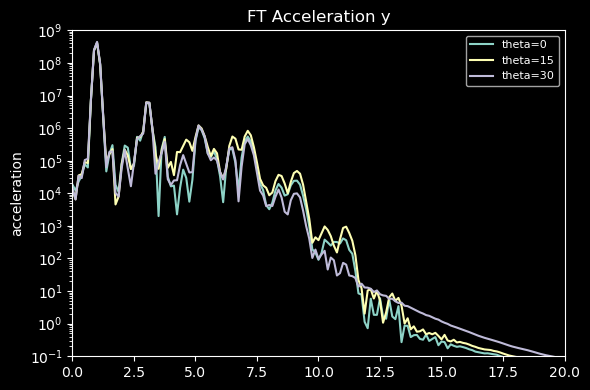

In [3]:
import numpy as np
import matplotlib.pyplot as plt
#plt.style.use('/home/lplaja/.matplotlib/stylelib/obsidian.mplstyle')

def gather_data(fnamelist):
    n_columns=len(fnamelist)

    t=[]
    filename=fnamelist[0]
    with open(filename, "r") as fh:  
        for line in fh:
            if line.startswith("#"):
                continue
            it, ix, iy = map(complex, line.split())
            t.append(np.real(it))

    t=np.array(t)

    n_rows=len(t)

    dipole_vel_x=np.zeros((n_rows, n_columns))
    dipole_vel_y=np.zeros((n_rows, n_columns))

    for i_file, filename in enumerate(fnamelist):

        ivel_x=[]
        ivel_y=[]
        with open(filename, "r") as fh:
            for line in fh:
                if line.startswith("#"):
                    continue
                it, ix, iy = map(complex, line.split())
                ivel_x.append(np.real(ix))
                ivel_y.append(np.real(iy))
# Caso de cambio de nt
#        if i_file==2:
#            dipole_vel_x[:,i_file]=ivel_x[::2]
#            dipole_vel_y[:,i_file]=ivel_y[::2]
#        else:
#            dipole_vel_x[:,i_file]=ivel_x
#            dipole_vel_y[:,i_file]=ivel_y
# caso dsin cambio de nt  
        dipole_vel_x[:,i_file]=ivel_x
        dipole_vel_y[:,i_file]=ivel_y       

        accel_x=np.gradient(np.real(dipole_vel_x), axis=0)
        accel_y=np.gradient(np.real(dipole_vel_y), axis=0)
        accel_x=accel_x[2:-3]
        accel_y=accel_y[2:-3]

    return t, dipole_vel_x, dipole_vel_y, accel_x, accel_y

#fnamelist=['graphene_prueba_dipole_velocity_nk300.txt','graphene_prueba_dipole_velocity_nk500.txt',
#           'graphene_prueba_dipole_velocity_nk900.txt']
#labels=['nk=300','nk=500','nk=900']

#fnamelist=['graphene_tilt_oscar_0_dipole_velocity.txt','graphene_tilt_oscar_15_dipole_velocity.txt', 
#           'graphene_tilt_oscar_30_dipole_velocity.txt']
#labels=['theta=0','theta=15','theta=30']

fnamelist=['graphene_tilt_oscar_0_dipole_velocity.txt','graphene_tilt_oscar_15_dipole_velocity.txt','graphene_tilt_oscar_30_dipole_velocity.txt']
labels=['theta=0','theta=15', 'theta=30']


t, dipole_vel_x, dipole_vel_y, accel_x, accel_y=gather_data(fnamelist)

nt=t.size-5
imask=int(nt/10)
mask=np.ones(nt)
igauss=np.arange(0,imask)
print(f'{igauss.shape=}   {mask.shape=}')
print(f'{nt=}   {imask=}')
print(f'{accel_x.shape=}   {accel_y.shape=}')
mask[nt-imask:]*=np.exp(-(igauss/10)**2)
for nn in range(3):
    accel_x[:,nn]*=mask
    accel_y[:,nn]*=mask


FT_npts=2*accel_x.shape[0]//8
FT_accel_x=np.fft.fft(accel_x, axis=0)[:FT_npts]
FT_accel_y=np.fft.fft(accel_y, axis=0)[:FT_npts]


plt.rcParams['legend.fontsize'] = 8

fig, ax=plt.subplots(1,1, figsize=(6,4))

#ax[0,0].plot(t, np.real(dipole_vel_y), label=labels)
#ax[0,0].set_xlabel("t")
#ax[0,0].set_ylabel("dipole velocity")
#ax[0,0].set_title("Dipole velocity y")
#ax[0,0].legend()
#ax[0,0].grid(False)

#ax[0,1].plot(t[2:-3], np.real(accel_y), label=labels)
#ax[0,1].set_xlabel("t")
#ax[0,1].set_ylabel("acceleration")
#ax[0,1].set_title("Acceleration y")
#ax[0,1].legend()
#ax[0,1].grid(False)

# ax[0].semilogy(np.abs(FT_accel_x)**2+np.abs(FT_accel_y)**2, label=labels)
# ax[0].set_xlabel("")
# ax[0].set_ylabel("acceleration")
# ax[0].set_title("FT Acceleration")
# ax[0].legend()
# ax[0].grid(False)

w=np.array([n/8 for n in range(len(np.abs(FT_accel_y)))])
ax.semilogy(w,np.abs(FT_accel_x)**2+np.abs(FT_accel_y)**2, label=labels)
ax.set_xlabel("")
ax.set_ylabel("acceleration")
ax.set_title("FT Acceleration y")
ax.legend()
ax.set_xlim(0,20)
ax.set_ylim(1e-1,1e9)
ax.grid(False)

plt.tight_layout()

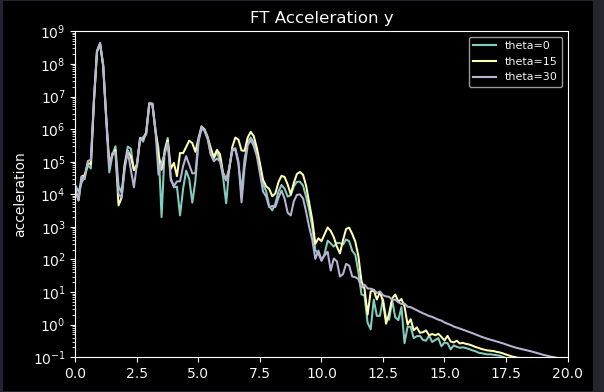